# Week 4 Lecture: Logistic Regression for Classification

This week we are going to use the movie dataset to try to answer this question: 
        
- **Can we predict whether a movie will be a box office hit based on its characteristics?**

For classification we will use a **logistic regression model**.

## What is Logistic Regression?

Logistic regression is a statistical method for modeling the relationship between:
- A **binary response variable** (or dependent variable, outcome) - a yes/no outcome we want to predict (e.g., hit vs. flop)

- One or more **predictor variables** (or independent variables, features) - information we use to make predictions

- The main idea is: if we have past movies where we know both the characteristics and whether they were hits, we can **learn** a rule that uses the characteristics to predict if new movies will be hits.

## Why Not Use Linear Regression for Classification?

You might wonder: why can't we just use linear regression to predict a 0/1 outcome?

**Problems with linear regression for binary outcomes:**

1. **Predictions outside [0,1]**: Linear regression can predict values less than 0 or greater than 1, which don't make sense as probabilities.

2. **Non-constant variance**: The variance of a binary outcome depends on the probability, violating linear regression assumptions.

3. **Non-linear relationship**: The relationship between predictors and a probability is inherently non-linear (S-shaped, not straight).

**Logistic regression solves these problems** by:
- Modeling the probability of the outcome being 1
- Using a transformation that keeps predictions between 0 and 1
- Properly accounting for the binary nature of the data

## The Logistic Regression Model (Mathematically)

Logistic regression models the **probability** that $y = 1$ given the predictors:

$$P(y = 1 | x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

This is equivalent to modeling the **log-odds** (or logit) as a linear function:

$$\log\left(\frac{P(y=1)}{1-P(y=1)}\right) = \beta_0 + \beta_1 x$$

And the **odds**:

$$\frac{P(y=1)}{1-P(y=1)}=\exp(\beta_0+\beta_1x_1)$$


Where:
- $P(y=1|x)$ is the probability of the outcome being 1 (e.g., movie is a hit)
- $\beta_0$ is the intercept (log-odds when $x = 0$)
- $\beta_1$ is the slope (change in log-odds when $x$ increases by 1)
- The fraction $\frac{P(y=1)}{1-P(y=1)}$ is called the **odds** (how likely it is to happen divided by how likely it is not to happen)

With multiple predictors:

$$P(y=1|x)=p(x)=\frac{1}{1+\exp\{-(\beta_0+\beta_1 x_1+\cdots+\beta_p x_p)\}}$$

Which gives the **log-odds** (or logit) as a linear function:

$$\log\left(\frac{P(y=1)}{1-P(y=1)}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

And the **odds**:

$$\frac{P(y=1)}{1-P(y=1)}=\exp(\beta_0+\beta_1x_1+\cdots+\beta_p x_p)$$

Exponentiating shows how effects combine multiplicatively on the odds because of the property of exponentials: $\exp(a+b)=\exp(a)\exp(b)$

## The Logistic (Sigmoid) Function

The key to logistic regression is the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This function:
- Takes any real number as input
- Always outputs a value between 0 and 1
- Has an S-shape (sigmoid curve)
- When $z = 0$, output is 0.5
- As $z \to \infty$, output approaches 1
- As $z \to -\infty$, output approaches 0

## Interpreting Coefficients: Odds Ratios

In logistic regression, exponentiating a coefficient gives an odds ratio (OR).

$$\text{OR for a 1-unit increase in } x_1
=\frac{\text{odds}(x_1+1)}{\text{odds}(x_1)}
=\exp(\beta_1)
\quad (\text{holding other predictors fixed})$$

Specifically:

- Intercept $\beta_0$: when $x_1=0$ (and other predictors =0, if present), the odds of $y=1$ are $\exp(\beta_0)$.
- Slope $\beta_1$: increasing $x_1$ by 1 multiplies the odds by $\exp(\beta_1)$.
- If $\beta_1>0$, then $\exp(\beta_1)>1$: odds increase as $x_1$ increases.
- If $\beta_1<0$, then $\exp(\beta_1)<1$: odds decrease as $x_1$ increases.
- If $\beta_1=0$, then $\exp(\beta_1)=1$: odds don’t change with $x_1$.



## Interpreting Coefficients: Specific Examples of Odds Ratios

- $e^{\beta_1}$ is the **odds ratio** associated with a one-unit increase in $x_1$

- If $e^{\beta_1} = 2$, then a one-unit increase in $x_1$ **doubles** the odds of success

- If $e^{\beta_1} = 0.5$, then a one-unit increase in $x_1$ **halves** the odds of success

- If $e^{\beta_1} = 1$, the predictor has no effect on the odds

**Example interpretation:**
If we're predicting whether a movie is a hit, and the $\beta_1$ coefficient for `vote_average` is 0.62:
- $e^{0.62} = 1.86$
- For each 1-point increase in vote average, the odds of being a hit increase by about 86%

## Making Predictions: Probability Threshold

When we make predictions from a fitted logistic regression model, we predict a **probability** between 0 and 1. To make a binary classification, we need a **decision threshold**:

- Typically, we use threshold = 0.5
- If $P(y=1|x) \geq 0.5$, predict class 1 (hit)
- If $P(y=1|x) < 0.5$, predict class 0 (flop)

The threshold can be adjusted based on:
- The relative costs of different types of errors
- The class balance in your data

## How Do We Fit Logistic Regression?

Unlike linear regression (which uses least squares), logistic regression is fit using **maximum likelihood estimation (MLE)**:

1. We write down the likelihood of observing our data given the model parameters

2. We find the parameter values that **maximize** this likelihood

3. This is done numerically using optimization algorithms

The likelihood for logistic regression:
$$L(\beta) = \prod_{i=1}^{n} p_i^{y_i} (1-p_i)^{1-y_i}$$

where $p_i = P(y_i = 1 | x_i, \beta)$

## Evaluating Classification Models

For classification, we use different metrics than for regression:

**Confusion Matrix:**
| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

**Common Metrics:**
- **Accuracy** = (TP + TN) / (TP + TN + FP + FN) - overall correctness
- **Precision** = TP / (TP + FP) - of predicted positives, how many are correct?
- **Recall (Sensitivity)** = TP / (TP + FN) - of actual positives, how many did we catch?
- **Specificity** = TN / (TN + FP) - of actual negatives, how many did we correctly identify?
- **F1 Score** = 2 × (Precision × Recall) / (Precision + Recall) - harmonic mean of precision and recall

## Python for Logistic Regression

- We will use Python's `statsmodels` to fit logistic regression models that explore the relationships between movie features and box office success. 

- We'll also use `sklearn` for model evaluation metrics like confusion matrix, accuracy, precision, and recall.

## Loading in the Data
- We will load the data with `pandas`

- **Data Source**: [The Movie Database (TMDB) API](https://www.themoviedb.org/)  

- **Date Range**: Movies released between 2015-01-01 and 2025-12-31

- The dataset contains information about 5,000 movies

- Recall that we will try to predict whether a movie is a hit from voter average (TMDB user rating) and other variables

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.float_format", "{:.2f}".format) 

movies = pd.read_csv("movies.csv")   
print(movies.shape)
movies.head(3)

(5000, 17)


,movie_id,title,revenue,popularity,budget,release_date,runtime,genres,vote_average,production_companies,production_countries,actors,crews,actor_avg_pop,crew_avg_pop,cast_count,crew_count
0,19995,Avatar,2923706026,54.76,237000000,2009-12-16,162,"Action,Adventure,Fantasy,Science Fiction",7.60,"Dune Entertainment,Lightstorm Entertainment,20...","US,GB","Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...","John Refoua(0.2), Stephen E. Rivkin(0.2), Terr...",5.92,1.08,67,991
1,299534,Avengers: Endgame,2799439100,17.86,356000000,2019-04-24,181,"Adventure,Science Fiction,Action",8.24,Marvel Studios,US,"Robert Downey Jr.(8.7), Chris Evans(7.2), Mark...","Paul Schneider(0.3), Louis D'Esposito(1.2), Ca...",8.80,0.46,107,608
2,76600,Avatar: The Way of Water,2353096253,61.95,350000000,2022-12-14,192,"Action,Adventure,Science Fiction",7.60,"20th Century Studios,Lightstorm Entertainment,...",US,"Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...","James Cameron(4.1), James Cameron(4.1), James ...",6.40,2.53,57,205


## Creating a Binary Outcome Variable

For logistic regression, we need a binary (0/1) outcome. Let's define a movie as a "hit" if its revenue exceeds a certain threshold.

- We'll define a **hit** as a movie where revenue > 3 × budget (i.e., the movie at least tripled its production budget)

- This is a simplification because in reality, marketing costs and other factors matter too

- Recall from last week that there were a lot of \$0 budgets, so let's clean those up first (treat them as missing)

In [46]:
# First, handle movies with budget = 0 (missing data)
movies_clean = movies[movies['budget'] > 0].copy()

# Create binary outcome: 1 if revenue > 3*budget, 0 otherwise
movies_clean['is_hit'] = (movies_clean['revenue'] > 3 * movies_clean['budget']).astype(int)

print(f"Number of movies with valid budget: {len(movies_clean)}")
print(f"\nDistribution of outcome:")
print(movies_clean['is_hit'].value_counts())
print(f"\nPercentage of hits: {movies_clean['is_hit'].mean()*100:.1f}%")

Number of movies with valid budget: 4159

Distribution of outcome:
is_hit
0    2165
1    1994
Name: count, dtype: int64

Percentage of hits: 47.9%


## Visualizing the Outcome Variable

Let's look at the distribution of hits (1) vs. flops (0)

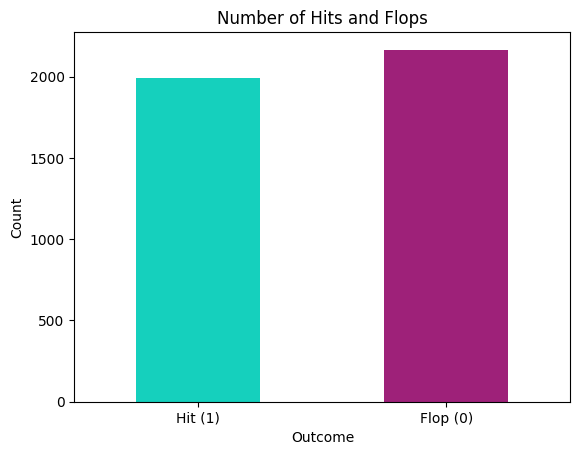

In [47]:
# Bar plot of hits vs flops (reindex just puts the 1s first in the output rather than 0s first)
counts = movies_clean['is_hit'].value_counts().reindex([1, 0])

ax = counts.plot(kind='bar', color=["#15d0bd", "#9e2179"])
ax.set_xticklabels(['Hit (1)', 'Flop (0)'], rotation=0)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Number of Hits and Flops')
plt.show()

Now let's look at whether there is a pattern in the distribution of `vote_average` with movie hits and flops using a boxplot.

<Figure size 800x500 with 0 Axes>

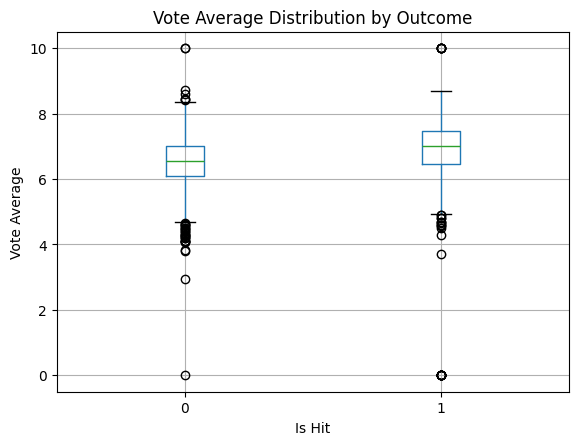

In [48]:
# Box plot of budget by outcome
plt.figure(figsize=(8, 5))
movies_clean.boxplot(column='vote_average', by='is_hit')
plt.xlabel('Is Hit')
plt.ylabel('Vote Average')
plt.title('Vote Average Distribution by Outcome')
plt.suptitle('') 
plt.show()

#### Do you see any evidence of a relationship between `vote_aveage` and `is_hit`?

## Simple Logistic Regression: Predicting Hit from Vote Average

Let's start with a simple model using only `vote_average` to predict whether a movie `is_hit`.

- We use `statsmodels` function `Logit` to fit the logistic regression

- Vote average is continuous on a 0-10 scale, so coefficients represent change per 1-point increase in average voter rating

In [49]:
# Prepare data into X and y, add intercept (constant)!
X = movies_clean['vote_average']
y = movies_clean['is_hit']
X_with_const = sm.add_constant(X)

# Fit logistic regression
model = sm.Logit(y, X_with_const).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.664571
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 is_hit   No. Observations:                 4159
Model:                          Logit   Df Residuals:                     4157
Method:                           MLE   Df Model:                            1
Date:                Wed, 28 Jan 2026   Pseudo R-squ.:                 0.04006
Time:                        15:05:50   Log-Likelihood:                -2763.9
converged:                       True   LL-Null:                       -2879.3
Covariance Type:            nonrobust   LLR p-value:                 4.267e-52
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -4.2766      0.299    -14.324      0.000      -4.862      -3.691
vote_average     0.6229      0.044     14.167      0.000       0.537       0.709
================================================================================
"""

## Interpreting the Logistic Regression Output

Let's interpret the coefficients in terms of odds ratios. Don't forget to

- exponentiate the model prameters (use `np.exp(model.params)`) to get odds ratios for interpretation

- 100\%(OR-1) converts the multiplicative change of an OR to a percent change in odds, which is nice for interpretation

$$\text{\% change} = \frac{\text{new} - \text{old}}{\text{old}} \times 100\%
= \frac{\text{OR}\cdot \text{old} - \text{old}}{\text{old}} \times 100\%
= (OR - 1)\times 100\%$$

In [50]:
# Calculate odds ratios
odds_ratios = np.exp(model.params)
print("Odds Ratios:")
print(odds_ratios)

print(f"\nInterpretation:")
print(f"For each 1-point increase in vote average (user rating),")
print(f"the odds of being a hit are multiplied by {odds_ratios['vote_average']:.2f}")
print(f"\nIn other words, higher-rated movies are about {(odds_ratios['vote_average']-1)*100:.0f}% more likely to be hits.")

Odds Ratios:
const          0.01
vote_average   1.86
dtype: float64

Interpretation:
For each 1-point increase in vote average (user rating),
the odds of being a hit are multiplied by 1.86

In other words, higher-rated movies are about 86% more likely to be hits.


## Visualizing the Logistic Regression Curve

Let's plot the predicted probability of being a hit as a function of vote average.

**What to look for in this plot:**

- **The S-shaped (sigmoid) curve**: This is the hallmark of logistic regression. The curve shows how the predicted probability changes as vote average increases.

- **Steepness of the curve**: A steeper curve indicates that small changes in vote average lead to large changes in predicted probability. A flatter curve means the predictor has a weaker effect.

- **Where the curve crosses 0.5**: This is the "decision boundary" - movies with vote averages above this point are predicted as hits, below as flops.

- **Spread of actual outcomes**: The scatter points (0s and 1s) show where hits and flops actually fall. Ideally, we'd see most 1s (hits) on the right side where predicted probabilities are high, and most 0s (flops) on the left.

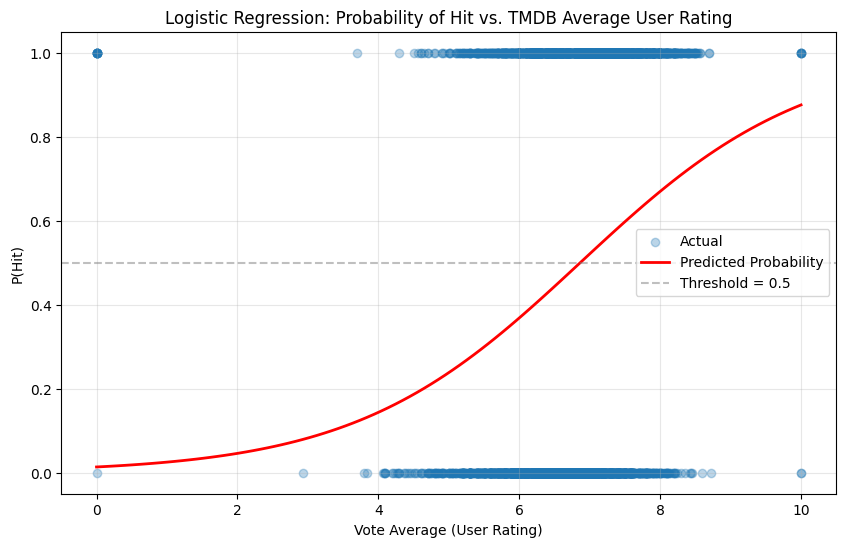

In [51]:
# Create range of vote_average values for prediction
vote_range = np.linspace(X.min(), X.max(), 100)
vote_range_const = sm.add_constant(vote_range)

# Get predicted probabilities
pred_probs = model.predict(vote_range_const)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(movies_clean['vote_average'], movies_clean['is_hit'], alpha=0.3, label='Actual')
plt.plot(vote_range, pred_probs, 'r-', linewidth=2, label='Predicted Probability')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold = 0.5')
plt.xlabel('Vote Average (User Rating)')
plt.ylabel('P(Hit)')
plt.title('Logistic Regression: Probability of Hit vs. TMDB Average User Rating')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Train/Test Split for Classification

Just like with linear regression, we need to evaluate our model on unseen data.

- Split into 80% training, 20% test
- Use `stratify` to ensure similar class proportions in both sets

In [52]:
from sklearn.model_selection import train_test_split

X = movies_clean[['vote_average']]
y = movies_clean['is_hit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print(f"Training set: {len(X_train)} movies")
print(f"Test set: {len(X_test)} movies")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

Training set: 3327 movies
Test set: 832 movies

Class distribution in training set:
is_hit
0   0.52
1   0.48
Name: proportion, dtype: float64


## Fit Model on Training Set and Make Predictions

Now we fit the logistic regression on the training data and use it to make predictions on the test set.

**Converting probabilities to class predictions:**

Logistic regression outputs a probability between 0 and 1 for each movie. But we need to make a binary decision: is this movie a hit or not?

We use a **threshold** (typically 0.5) to convert probabilities to class predictions:
- If predicted probability ≥ 0.5 → predict **Hit (1)**
- If predicted probability < 0.5 → predict **Flop (0)**

**Why 0.5?** It's the natural midpoint - if we think there's a greater than 50% chance of being a hit, we predict hit. However, we could adjust this threshold:
- **Lower threshold (e.g., 0.3)**: Predict more movies as hits → catches more actual hits (higher recall) but also more false positives
- **Higher threshold (e.g., 0.7)**: Predict fewer movies as hits → more confident predictions (higher precision) but may miss some actual hits


In [53]:
# Fit model on training set
X_train_const = sm.add_constant(X_train)
model = sm.Logit(y_train, X_train_const).fit()

# Make predictions on test set
X_test_const = sm.add_constant(X_test)
y_pred_prob = model.predict(X_test_const)

# Convert probabilities to class predictions (threshold = 0.5)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Model coefficients:")
print(model.params)
print(f"\nSample predictions (first 10):")
print(pd.DataFrame({'Actual': y_test[:10].values, 
                    'Vote Avg': X_test['vote_average'][:10].values,
                    'Predicted Prob': y_pred_prob[:10].values, 
                    'Predicted Class': y_pred[:10].values}))

Optimization terminated successfully.
         Current function value: 0.663303
         Iterations 5
Model coefficients:
const          -4.48
vote_average    0.65
dtype: float64

Sample predictions (first 10):
   Actual  Vote Avg  Predicted Prob  Predicted Class
0       1      7.95            0.67                1
1       0      6.50            0.44                0
2       1      6.64            0.46                0
3       0      7.25            0.56                1
4       1      7.40            0.59                1
5       0      7.56            0.61                1
6       1      7.29            0.57                1
7       1      7.40            0.59                1
8       1      7.90            0.66                1
9       1      6.78            0.49                0


### Evaluation Metrics

Now that we have predictions from our model, how do we evaluate how well it's doing? For classification, we use different metrics than for regression (where we used MSE, R2, etc.).



#### Confusion Matrix

A **confusion matrix** is a table that shows the counts of correct and incorrect predictions:

<table>
  <tr>
    <th></th>
    <th>Predicted Flop (0)</th>
    <th>Predicted Hit (1)</th>
  </tr>
  <tr>
    <td><b>Actual Flop (0)</b></td>
    <td>True Negative (TN)</td>
    <td>False Positive (FP)</td>
  </tr>
  <tr>
    <td><b>Actual Hit (1)</b></td>
    <td>False Negative (FN)</td>
    <td>True Positive (TP)</td>
  </tr>
</table>

- **True Positive (TP)**: We predicted hit, and it was actually a hit
- **True Negative (TN)**: We predicted flop, and it was actually a flop
- **False Positive (FP)**: We predicted hit, but it was actually a flop (Type I error)
- **False Negative (FN)**: We predicted flop, but it was actually a hit (Type II error)


### Classification Metrics

From the confusion matrix, we calculate several metrics:

**Accuracy** = $\frac{TP + TN}{TP + TN + FP + FN}$  What proportion of all predictions were correct?

**Precision** = $\frac{TP}{TP + FP}$  Of movies we predicted as hits, what proportion were actually hits?

**Recall (Sensitivity)** = $\frac{TP}{TP + FN}$  Of movies that were actually hits, what proportion did we correctly identify?

**F1 Score** = $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$  The harmonic mean of precision and recall (balances both)

Note: all of these metrics are bounded between 0 and 1.

### When to use which metric?

- **Accuracy** is intuitive but can be misleading with imbalanced classes

- **Precision** matters when the cost of false positives is high (e.g., don't want to recommend bad movies)

- **Recall** matters when the cost of false negatives is high (e.g., don't want to miss potential hits)

- **F1 Score** is useful when you want to balance precision and recall

Let's look at the confusion matrix for the fitted simple logistic model of movie hits and voter average

In [54]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print(f"\n             Predicted")
print(f"             Flop  Hit")
print(f"Actual Flop  {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"       Hit   {cm[1,0]:4d}  {cm[1,1]:4d}")

Confusion Matrix:
[[298 135]
 [172 227]]

             Predicted
             Flop  Hit
Actual Flop   298   135
       Hit    172   227


In [55]:
# Classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Classification Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Classification Metrics:
Accuracy:  0.6310
Precision: 0.6271
Recall:    0.5689
F1 Score:  0.5966


- Accuracy = 0.631. We are correct 63.1\% of the time overall. This can look “good” even for a weak model if one class is much more common, so it’s best compared to a baseline (e.g., always predicting the majority class).

- Precision = 0.627 (for the positive class, usually “Hit = 1”). Among the movies you predicted as Hit, about 62.7\% were actually Hits. Interpretation: when the model says “Hit,” it’s right about 63\% of the time.

- Recall = 0.569. Of all the true Hits, the model correctly identifies about 56.9\%. Interpretation: it misses about 43.1\% of real Hits (false negatives).

- F1 = 0.597. A single summary of precision/recall (higher is better). Around 0.60 suggests moderate performance: not terrible, not strong.

## Multiple Logistic Regression

Let's improve our model by including more predictors. We'll use:
- Budget
- Popularity score
- Average actor popularity
- Runtime
- Vote average
- Genre indicators

In [56]:
# Create budget in millions for easier interpretation
movies_clean['budget_millions'] = movies_clean['budget'] / 1e6


# Create genre indicators
high_revenue_genres = ['Action', 'Adventure', 'Comedy', 'Drama']

for genre in high_revenue_genres:
    movies_clean[f'{genre.lower()}'] = movies_clean['genres'].fillna('').str.contains(genre).astype(int)

# Define predictor columns
predictor_cols = ['budget_millions', 'popularity', 'actor_avg_pop', 'runtime', 'vote_average',
                  'action', 'adventure', 'comedy', 'drama']

# Double check to remove missing data
movies_clean = movies_clean.dropna(subset=predictor_cols).copy()

# Prepare data
X = movies_clean[predictor_cols]
y = movies_clean['is_hit']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

In [57]:
# Fit multiple logistic regression
X_train_const = sm.add_constant(X_train)
model_multi = sm.Logit(y_train, X_train_const).fit()

# Display coefficients and odds ratios
coefs = pd.DataFrame({
    'coef': model_multi.params,
    'odds_ratio': np.exp(model_multi.params),
    'p_value': model_multi.pvalues
})
print(coefs)

Optimization terminated successfully.
         Current function value: 0.642441
         Iterations 6
                 coef  odds_ratio  p_value
const           -4.44        0.01     0.00
budget_millions -0.01        0.99     0.00
popularity       0.02        1.02     0.01
actor_avg_pop   -0.04        0.96     0.16
runtime         -0.00        1.00     0.31
vote_average     0.76        2.13     0.00
action          -0.17        0.84     0.06
adventure       -0.03        0.97     0.73
comedy           0.11        1.12     0.19
drama           -0.55        0.58     0.00


In [58]:
# Evaluate on test set
X_test_const = sm.add_constant(X_test)
y_pred_prob = model_multi.predict(X_test_const)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"             Predicted")
print(f"             Flop  Hit")
print(f"Actual Flop  {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"       Hit   {cm[1,0]:4d}  {cm[1,1]:4d}")

# Metrics
print(f"\nClassification Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

Confusion Matrix:
             Predicted
             Flop  Hit
Actual Flop   301   132
       Hit    178   221

Classification Metrics:
Accuracy:  0.6274
Precision: 0.6261
Recall:    0.5539
F1 Score:  0.5878


#### How do these metrics look compared to the simple logistic regression?

## ROC Curve and AUC

The **ROC (Receiver Operating Characteristic) curve** shows the trade-off between true positive rate (recall) and false positive rate at different thresholds.

The **AUC (Area Under the Curve)** summarizes the overall performance:
- AUC = 0.5: No better than random guessing
- AUC = 1.0: Perfect classifier

In python we can calculate ROC and AUC easily from `sklearn.metrics` functions `roc_curve` and `roc_auc_score`

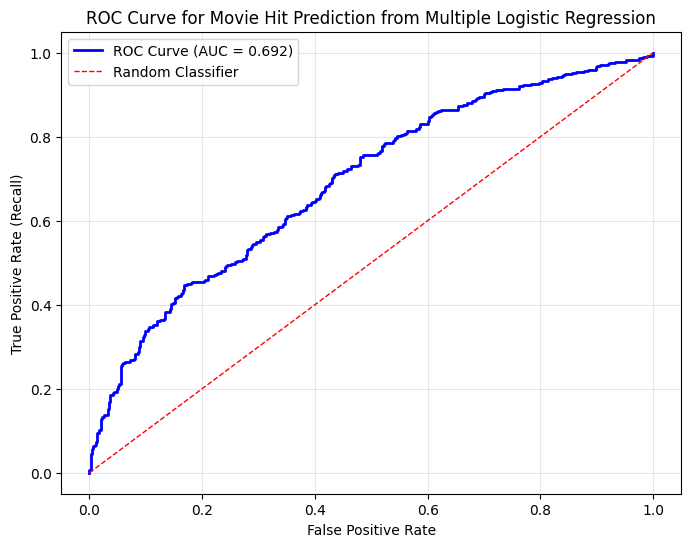

AUC:  0.6919


In [59]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for Movie Hit Prediction from Multiple Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC:  {auc:.4f}")

#### What you’re looking for on the curve

- The top-left corner (FPR=0, TPR=1) is ideal: catch all positives with no false positives.

- The diagonal line from (0,0) to (1,1) is random guessing (no discrimination).

- Curves that bow far above the diagonal are better.

## Summary: Logistic Regression for Classification

In this lecture, we explored how to build and evaluate logistic regression models for classifying movies as hits or flops.

### Key Concepts

**1. Logistic Regression Basics**
- Models the probability of a binary outcome
- Uses the sigmoid function to keep predictions between 0 and 1
- Coefficients are interpreted as log-odds, we exponentiate the coefficients to get odds ratios

**2. Model Fitting**
- Uses maximum likelihood estimation (not least squares)
- Can include multiple predictors just like linear regression

**3. Making Predictions**
- Model outputs probabilities
- Use a threshold (typically 0.5) to convert to class predictions

**4. Evaluation Metrics**
- Confusion matrix shows TP, TN, FP, FN
- Accuracy: overall correctness
- Precision: of predicted positives, how many are correct?
- Recall: of actual positives, how many did we catch?
- F1 Score: harmonic mean of precision and recall
- ROC Curve and AUC: overall discriminative ability

### Next Steps

To improve classification further, we could:
- Add more features (release timing, franchise status, etc.)
- Handle class imbalance if present
- Try other classification methods (decision trees, random forests)